In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('data/water_potability.csv')

# First look at the data
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Check shape and column info (data types, non-null counts)
print("Shape:", df.shape)
df.info()

Shape: (3276, 10)
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
# Check missing values in each column
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [5]:
# Statistical summary of numerical columns
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
# Check target class distribution
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

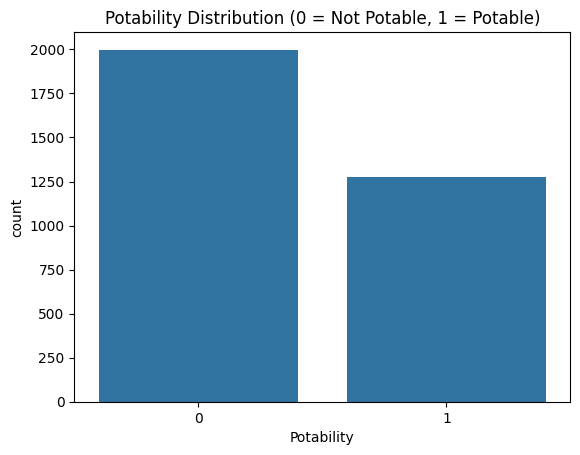

In [7]:
# Visualize target distribution
sns.countplot(x='Potability', data=df)
plt.title('Potability Distribution (0 = Not Potable, 1 = Potable)')
plt.show()

In [8]:
# Fill missing values using median of each column
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

# Verify no missing values remain
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

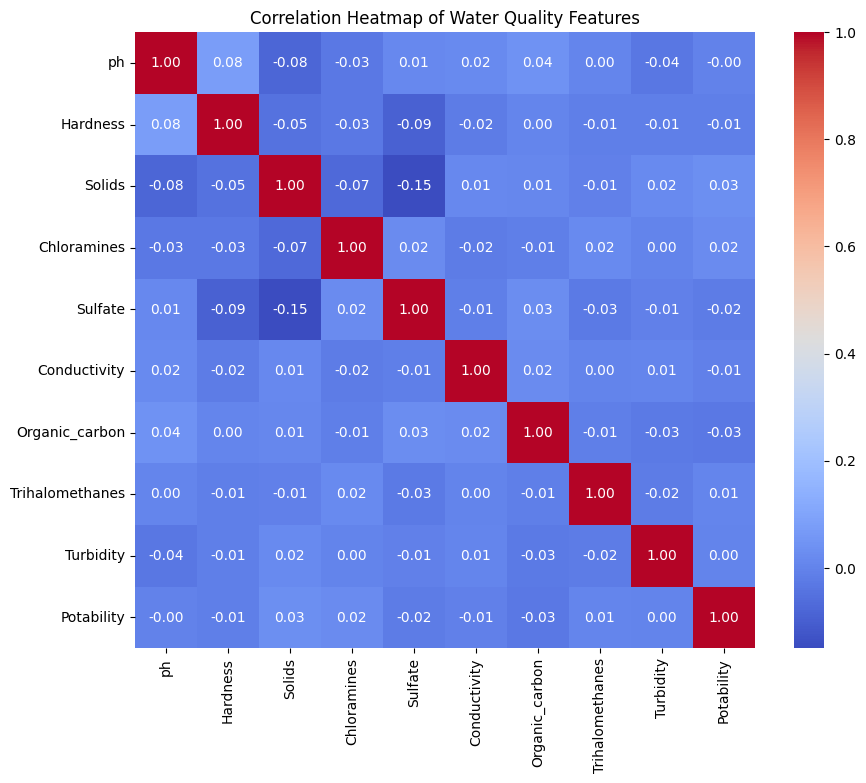

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()

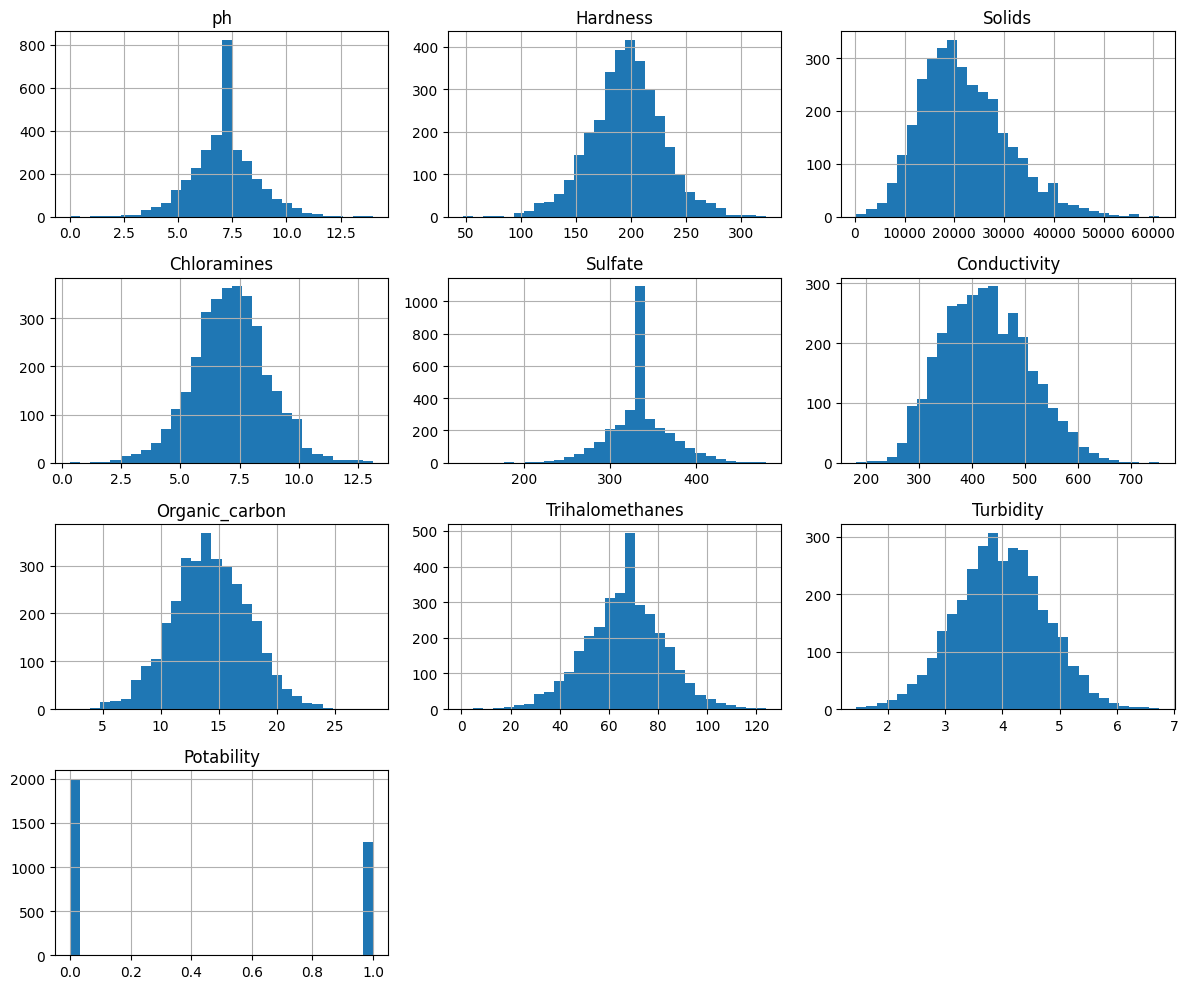

In [10]:
# Distribution of each feature
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2620, 9)
Test shape: (656, 9)


In [13]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done successfully!")

Scaling done successfully!


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaled data

print("Both models trained successfully!")

Both models trained successfully!


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions from both models
log_reg_preds = log_reg.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)

# Evaluate Logistic Regression
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Precision:", precision_score(y_test, log_reg_preds))
print("Recall:", recall_score(y_test, log_reg_preds))
print("F1-Score:", f1_score(y_test, log_reg_preds))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-Score:", f1_score(y_test, rf_preds))

=== Logistic Regression ===
Accuracy: 0.6097560975609756
Precision: 0.0
Recall: 0.0
F1-Score: 0.0

=== Random Forest ===
Accuracy: 0.6585365853658537
Precision: 0.6311475409836066
Recall: 0.30078125
F1-Score: 0.4074074074074074


d:\Anaconda\envs\anaconda_environment\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


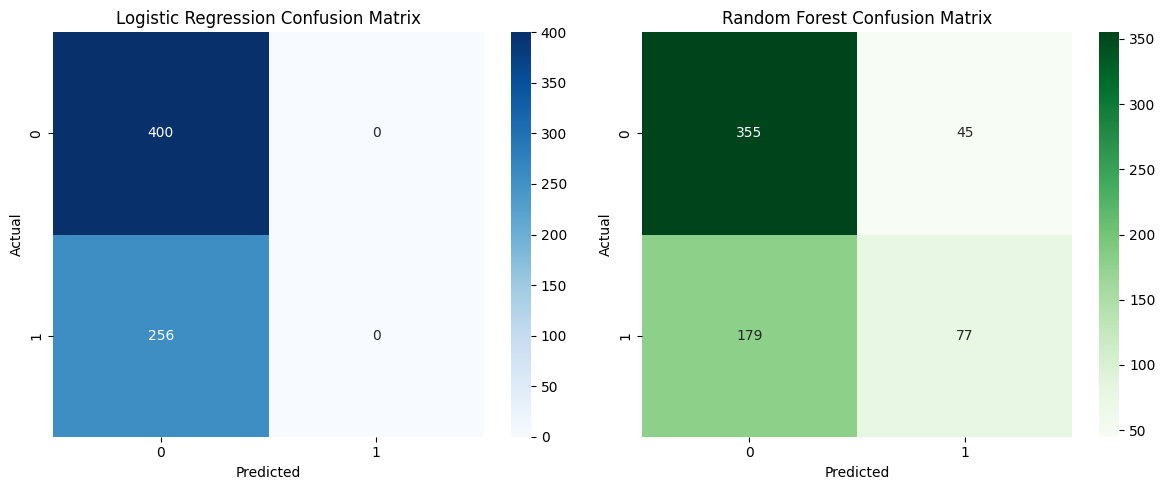

In [16]:
# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, log_reg_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [18]:
# Retrain with class_weight='balanced' to handle imbalance
log_reg_balanced = LogisticRegression(random_state=42, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)

rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

# Predictions
log_reg_bal_preds = log_reg_balanced.predict(X_test_scaled)
rf_bal_preds = rf_balanced.predict(X_test)

# Evaluate
print("=== Logistic Regression (Balanced) ===")
print("Accuracy:", accuracy_score(y_test, log_reg_bal_preds))
print("Precision:", precision_score(y_test, log_reg_bal_preds))
print("Recall:", recall_score(y_test, log_reg_bal_preds))
print("F1-Score:", f1_score(y_test, log_reg_bal_preds))

print("\n=== Random Forest (Balanced) ===")
print("Accuracy:", accuracy_score(y_test, rf_bal_preds))
print("Precision:", precision_score(y_test, rf_bal_preds))
print("Recall:", recall_score(y_test, rf_bal_preds))
print("F1-Score:", f1_score(y_test, rf_bal_preds))

=== Logistic Regression (Balanced) ===
Accuracy: 0.5259146341463414
Precision: 0.41590214067278286
Recall: 0.53125
F1-Score: 0.4665523156089194

=== Random Forest (Balanced) ===
Accuracy: 0.6402439024390244
Precision: 0.5526315789473685
Recall: 0.41015625
F1-Score: 0.47085201793721976


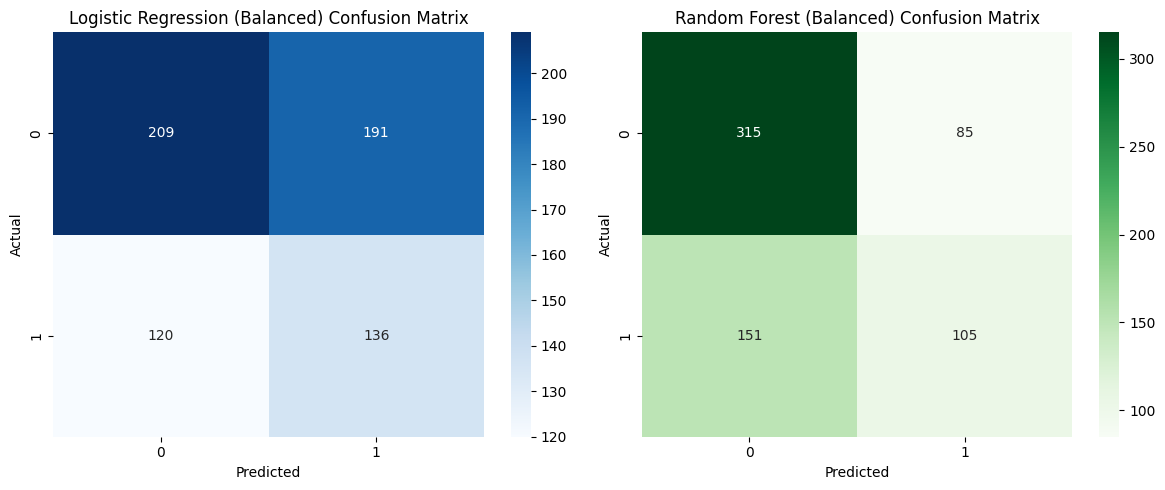

In [19]:
# Confusion matrices for balanced models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, log_reg_bal_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression (Balanced) Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_bal_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest (Balanced) Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Model Comparison and Conclusion

Both Logistic Regression and Random Forest were trained on the water potability dataset. 
Initial results showed Logistic Regression predicting only the majority class (Not Potable), 
resulting in 0 Precision and Recall. This happened because the dataset has weak linear 
correlation between features and the target (as seen in the correlation heatmap), which 
Logistic Regression struggles with since it can only draw linear decision boundaries.

After applying `class_weight='balanced'` to address class imbalance, both models improved 
in predicting the minority class (Potable). Random Forest performed better overall, achieving 
64% accuracy and a more balanced Precision-Recall trade-off (F1-Score: 0.47), because it can 
capture non-linear patterns in the data that Logistic Regression cannot. Random Forest is 
selected as the final model for this task.

In [22]:
import joblib

# Save the final chosen model (Random Forest - balanced)
joblib.dump(rf_balanced, 'water_potability_model.pk1')

# Save the scaler too (not strictly needed for RF, but good practice if switching models later)
joblib.dump(scaler, 'scaler.pk1')

print("Model saved successfully!")

Model saved successfully!
